# 03 — RFM & Enrichissement externe (météo / jours fériés)

*Notebook*

> **Dépendances :** Nécessite la table jointe customers+articles+transactions produite par **02_EDA_Produits_Transactions.ipynb**.


## 0. Reprise depuis les notebooks précédents

Nécessite `nb01_customers.pkl` (**01**) et `nb02_transactions_accumulators.pkl` (**02**). Exécute ces deux notebooks au préalable sur le même `BASE_PATH`/Drive.

In [1]:
import os, pickle, gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
sns.set_palette("husl")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/HM_dataset/"
except ImportError:
    print("Google Colab non détecté -> lecture des fichiers dans le dossier courant.")
    BASE_PATH = "./"

CUSTOMERS_PATH = os.path.join(BASE_PATH, "customers.csv")
ARTICLES_PATH = os.path.join(BASE_PATH, "articles.csv")
TRANSACTIONS_PATH = os.path.join(BASE_PATH, "transactions_train.csv")
INTERMEDIATE_DIR = os.path.join(BASE_PATH, "intermediate/")
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)

try:
    with open(os.path.join(INTERMEDIATE_DIR, "nb01_customers.pkl"), "rb") as f:
        customers = pickle.load(f)
    with open(os.path.join(INTERMEDIATE_DIR, "nb02_transactions_accumulators.pkl"), "rb") as f:
        _acc = pickle.load(f)
    customer_stats = _acc["customer_stats"]
    daily_revenue = _acc["daily_revenue"]
    daily_count = _acc["daily_count"]
    product_group_revenue = _acc["product_group_revenue"]
    print(f"Repris : customers {customers.shape}, {len(customer_stats):,} clients acheteurs")
except FileNotFoundError as e:
    raise FileNotFoundError(
        "Fichier(s) intermédiaire(s) introuvable(s). Exécute 01_EDA_Nettoyage_Clients.ipynb "
        "puis 02_EDA_Produits_Transactions.ipynb (jusqu'à leur cellule d'export) avant ce notebook."
    ) from e


Mounted at /content/drive
Repris : customers (1371980, 6), 1,362,281 clients acheteurs


## 11. Analyse approfondie des clients et des produits achetés (RFM)

On exploite ici les accumulateurs `customer_stats` (montant total dépensé et nombre d'achats par
client) et `product_group_revenue` (chiffre d'affaires par catégorie de produit), calculés pendant
le même passage par blocs que la section 9, donc sans relire le fichier une seconde fois.


### 11.1 Profil d'achat des clients (Fréquence x Montant)

In [2]:
customer_rfm = pd.DataFrame.from_dict(
    customer_stats, orient="index", columns=["montant_total", "nb_achats"]
)
customer_rfm.index.name = "customer_id"
print(f"Nombre de clients ayant acheté : {len(customer_rfm):,}")
customer_rfm.describe()


Nombre de clients ayant acheté : 1,362,281


,montant_total,nb_achats
count,1.362281e+06,1.362281e+06
mean,6.493858e-01,2.333463e+01
std,1.197582e+00,3.924225e+01
min,7.627119e-04,1.000000e+00
25%,8.806780e-02,3.000000e+00
50%,2.455932e-01,9.000000e+00
75%,7.011864e-01,2.700000e+01
max,5.767641e+01,1.895000e+03


Interprétation des principaux indicateurs
| Observation                 | Analyse                                                                                                                                                           |
| --------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Nombre de clients acheteurs | 1 362 281 clients ont réalisé au moins un achat dans la base H&M.                                                                                                 |
| Nombre d'achats médian      | 50% des clients ont effectué au maximum 9 achats, ce qui montre une majorité de clients occasionnels.                                                             |
| Nombre d'achats moyen       | La moyenne de 23,33 achats est supérieure à la médiane, indiquant la présence de clients très actifs qui augmentent la moyenne.                                   |
| Montant dépensé médian      | La moitié des clients ont dépensé moins de 0,246, indiquant une concentration des dépenses sur un petit nombre de clients.                                        |
| Clients à forte valeur      | Certains clients atteignent jusqu'à 1 895 achats et 57,676 de montant total, représentant probablement des clients très fidèles.                                  |
| Distribution globale        | Les deux variables présentent une forte asymétrie : une majorité de clients ont un comportement d'achat modéré, tandis qu'une minorité génère une forte activité. |


Segmentation comportementale possible
| Segment client         | Caractéristiques                                              |
| ---------------------- | ------------------------------------------------------------- |
| Clients occasionnels   | Peu d'achats et faible montant dépensé                        |
| Clients réguliers      | Nombre d'achats supérieur à la médiane et activité récurrente |
| Clients à forte valeur | Nombre élevé d'achats et montant total important              |


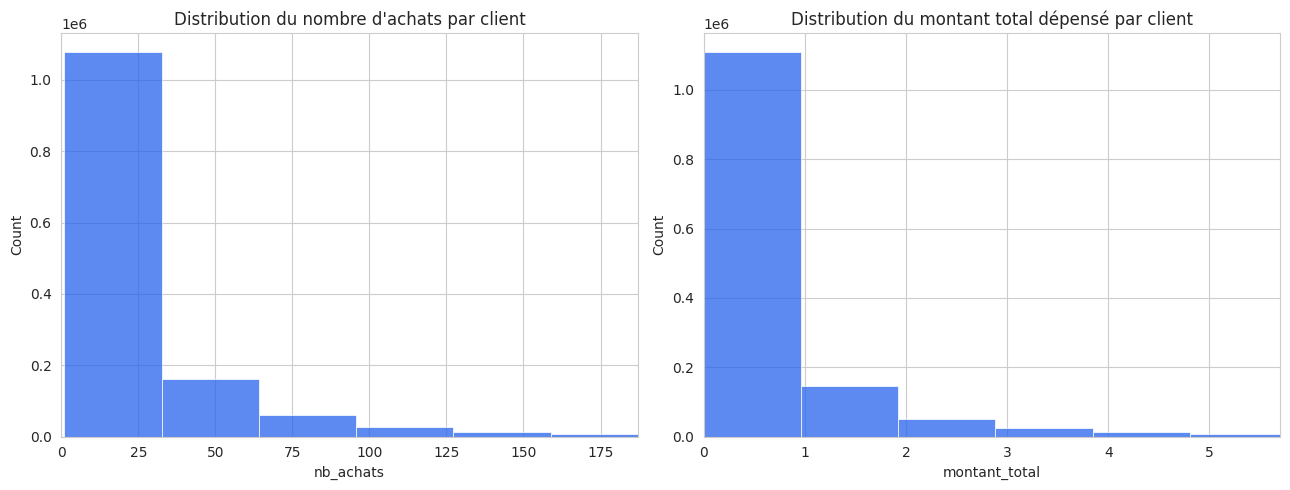

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(customer_rfm["nb_achats"], bins=60, ax=axes[0], color="#2563eb")
axes[0].set_title("Distribution du nombre d'achats par client")
axes[0].set_xlim(0, customer_rfm["nb_achats"].quantile(0.99))

sns.histplot(customer_rfm["montant_total"], bins=60, ax=axes[1], color="#2563eb")
axes[1].set_title("Distribution du montant total dépensé par client")
axes[1].set_xlim(0, customer_rfm["montant_total"].quantile(0.99))

plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** les deux distributions sont très **asymétriques à droite** (typique du
retail) : la majorité des clients achètent peu (médiane ~10 achats sur 2 ans), tandis qu'une
minorité de gros acheteurs tire fortement la moyenne vers le haut (jusqu'à plus de 2000 achats pour
le client le plus actif).

Ce profil justifie une segmentation par quantiles plutôt que par simple
moyenne.


### 11.2 Segmentation des clients par valeur (quartiles de montant dépensé)

In [4]:
customer_rfm["segment_valeur"] = pd.qcut(
    customer_rfm["montant_total"], q=4, labels=["Bas (Q1)", "Moyen-bas (Q2)", "Moyen-haut (Q3)", "Haut (Q4 - VIP)"]
)

segment_summary = customer_rfm.groupby("segment_valeur", observed=True).agg(
    nb_clients=("montant_total", "count"),
    montant_moyen=("montant_total", "mean"),
    achats_moyen=("nb_achats", "mean"),
)
segment_summary["part_CA_totale_%"] = (
    customer_rfm.groupby("segment_valeur", observed=True)["montant_total"].sum()
    / customer_rfm["montant_total"].sum() * 100
).round(1)
segment_summary


,nb_clients,montant_moyen,achats_moyen,part_CA_totale_%
segment_valeur,,,,
Bas (Q1),340644,0.048606,2.209773,1.9
Moyen-bas (Q2),340550,0.154571,6.177692,6.0
Moyen-haut (Q3),340517,0.428340,16.722507,16.5
Haut (Q4 - VIP),340570,1.966093,68.231104,75.7


**Analyse des segments clients**

| Observation                        | Analyse                                                                                                                                                         |
| ---------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Répartition équilibrée des clients | Les quatre segments contiennent environ **340 000 clients chacun**, car ils sont construits selon les quartiles de valeur d'achat.                              |
| Segment Bas (Q1)                   | Représente 25% des clients mais génère seulement **1,9% du chiffre d'affaires**. Ces clients ont un faible engagement avec seulement **2,2 achats en moyenne**. |
| Segment Moyen-bas (Q2)             | Génère **6% du CA** avec environ **6 achats par client**. Ce segment présente un potentiel d'évolution vers des clients plus actifs.                            |
| Segment Moyen-haut (Q3)            | Représente une clientèle plus engagée avec environ **16,7 achats en moyenne** et contribue à **16,5% du CA**.                                                   |
| Segment Haut (Q4 - VIP)            | Bien qu'il représente seulement **25% des clients**, ce segment génère **75,7% du chiffre d'affaires total** avec une moyenne de **68 achats par client**.      |


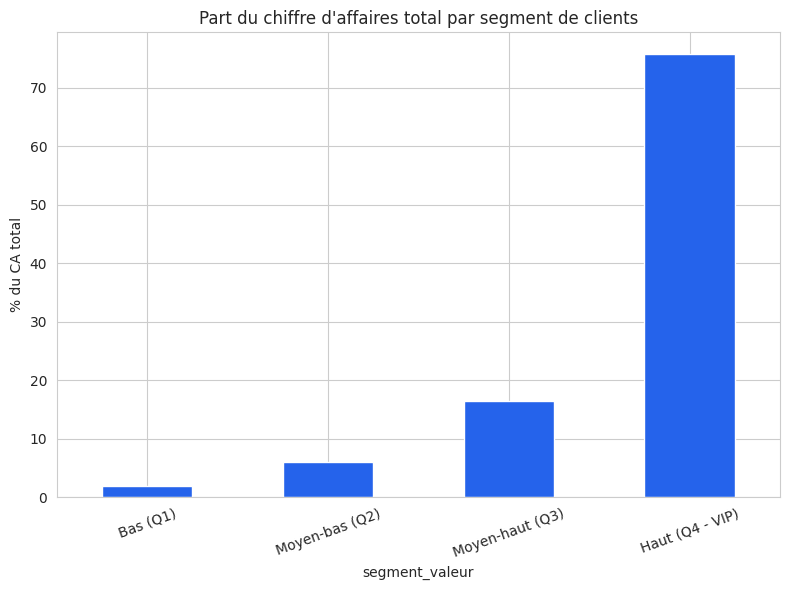

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
segment_summary["part_CA_totale_%"].plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("Part du chiffre d'affaires total par segment de clients")
ax.set_ylabel("% du CA total")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :**

`La règle de Pareto indique souvent qu'environ 20% des clients peuvent générer environ 80% de la valeur d'une entreprise.`

Conformément à une logique de type Pareto (80/20), le segment **Haut
(Q4 - VIP)**  25% des clients acheteurs concentre une part très largement supérieure à 25% du
chiffre d'affaires total, alors que le segment **Bas (Q1)** n'en représente qu'une fraction
marginale.

Ces clients VIP sont la cible prioritaire pour la fidélisation et les actions
marketing personnalisées.


### 11.3 Profil démographique des clients VIP vs autres

In [6]:
customer_rfm_named = customer_rfm.reset_index()
customer_profile = customer_rfm_named.merge(
    customers[["customer_id", "age", "age_group", "club_member_status"]], on="customer_id", how="left"
)

vip_vs_others = customer_profile.groupby(
    customer_profile["segment_valeur"] == "Haut (Q4 - VIP)"
)["age"].agg(["mean", "median"])
vip_vs_others.index = ["Autres clients", "Clients VIP (Q4)"]
vip_vs_others


,mean,median
Autres clients,36.358133,32.0
Clients VIP (Q4),36.306131,31.0


La table ci-dessus compare l’âge des clients VIP (Q4) avec celui des autres clients afin d’identifier s'il existe une différence démographique entre les segments de valeur.

**Analyse**

| Observation                                 | Interprétation                                                                                                                                                                                          |
| ------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Âge moyen presque identique                 | Les clients VIP (36,31 ans) ont un âge moyen très proche des autres clients (36,36 ans). L'âge seul ne semble donc pas être un facteur différenciant majeur pour identifier les clients à forte valeur. |
| Médiane légèrement plus faible chez les VIP | La moitié des clients VIP ont moins de 31 ans, contre 32 ans pour les autres clients. Les VIP ne sont donc pas significativement plus âgés ; ils sont même légèrement plus jeunes selon la médiane.     |
| Absence de différence démographique forte   | La valeur client semble davantage liée au comportement d'achat (fréquence, montant dépensé, fidélité) qu'à l'âge.                                                                                       |


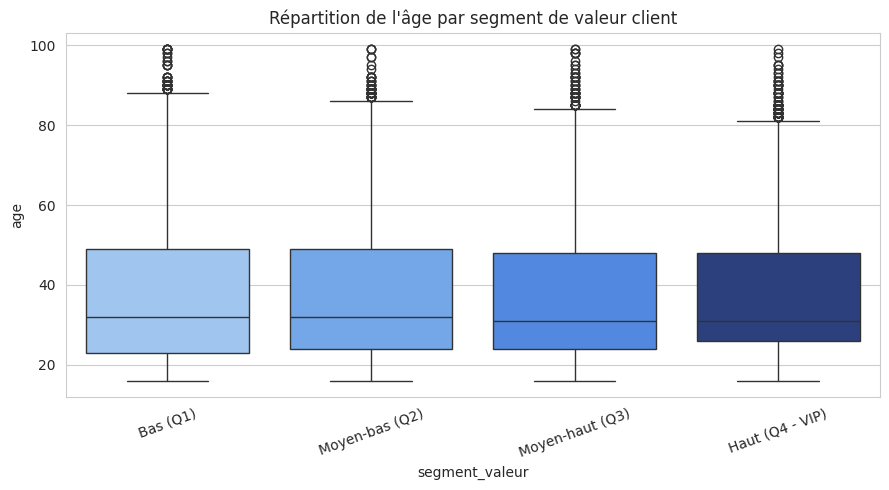

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=customer_profile, x="segment_valeur", y="age", ax=ax,
            palette=["#93c5fd", "#60a5fa", "#3b82f6", "#1e3a8a"])
ax.set_title("Répartition de l'âge par segment de valeur client")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
plt.close('all')


### 11.4 Chiffre d'affaires par catégorie de produit

In [8]:
pg_revenue = pd.Series(product_group_revenue).sort_values(ascending=False)
pg_revenue_pct = (pg_revenue / pg_revenue.sum() * 100).round(1)
pd.DataFrame({"CA": pg_revenue.round(1), "part_%": pg_revenue_pct})


,CA,part_%
Garment Upper body,338981.8,38.3
Garment Lower body,231774.6,26.2
Garment Full body,128478.9,14.5
Swimwear,57628.2,6.5
Underwear,54395.9,6.1
Shoes,28888.4,3.3
Accessories,24893.8,2.8
Nightwear,8852.8,1.0
Socks & Tights,7811.1,0.9
Unknown,2598.7,0.3


**Analyse de la contribution des catégories**

| Observation                              | Interprétation                                                                                                                                                                                                                  |
| ---------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Domination des vêtements principaux      | Les catégories **Garment Upper body**, **Garment Lower body** et **Garment Full body** représentent ensemble environ **79% du chiffre d'affaires total**. Les vêtements constituent donc le cœur de l'activité commerciale H&M. |
| Garment Upper body en première position  | Les produits du haut du corps (tops, pulls, vestes, chemises...) génèrent à eux seuls **38,3% du CA**, ce qui en fait la catégorie la plus stratégique.                                                                         |
| Garment Lower body deuxième contributeur | Les articles du bas du corps (pantalons, jeans, jupes...) représentent **26,2% du CA**, confirmant leur importance dans les achats clients.                                                                                     |
| Catégories complémentaires               | Le swimwear et l'underwear contribuent respectivement à **6,5%** et **6,1%** du CA, représentant des segments secondaires mais significatifs.                                                                                   |
| Faible contribution des accessoires      | Les chaussures (**3,3%**) et accessoires (**2,8%**) génèrent une part plus faible du chiffre d'affaires comparée aux vêtements.                                                                                                 |
| Catégories marginales                    | Les catégories comme cosmétique, mobilier, textile intérieur ou papeterie représentent une contribution quasi nulle dans cette base.                                                                                            |


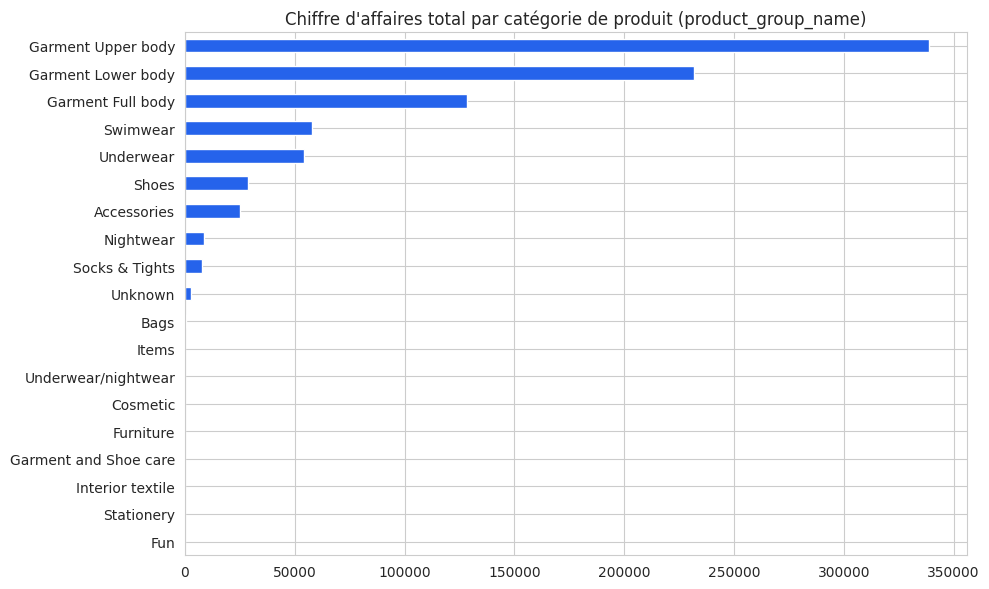

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
pg_revenue.plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Chiffre d'affaires total par catégorie de produit (product_group_name)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** `Garment Upper body` et `Garment Lower body` dominent très largement le
chiffre d'affaires, cohérent avec leur poids à la fois dans le catalogue (section 8) et dans le
volume de ventes (section 9). Cette convergence poids-catalogue / poids-CA suggère une offre bien
calibrée sur ces catégories phares.


## 12. Enrichissement météo et jours fériés

`transactions_train.csv` ne contient aucune donnée géographique ni météo. Pour interpréter les
variations du **nombre de transactions et du chiffre d'affaires (CA)** selon la météo et les jours
fériés, on enrichit le calendrier des ventes avec deux API externes, gratuites et sans clé :

- **[Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api)** (API historique
  ERA5) : température moyenne et précipitations quotidiennes.
- **[Nager.Date](https://date.nager.at/api)** : jours fériés publics.

> **Hypothèse de localisation :** le dataset ne précise pas le pays des clients/magasins. H&M étant
> une entreprise suédoise, on utilise **Stockholm** (59.33°N, 18.06°E) comme proxy raisonnable du
> marché domestique — à ajuster si tu disposes d'une répartition géographique réelle des ventes
> (ex. via `postal_code`, bien que celui-ci soit hashé et donc inexploitable directement ici).
>
> **Note d'exécution :** ces appels nécessitent une connexion internet (disponible sur Colab). La
> logique ci-dessous a été validée avec des réponses simulées conformes au schéma documenté de
> chaque API, mais n'a pas pu être testée en conditions réelles dans l'environnement de génération
> de ce notebook (accès réseau restreint). Vérifie le résultat du premier appel avant de poursuivre.


### 12.1 Récupération des données météo (Open-Meteo)

In [10]:
import requests

LATITUDE, LONGITUDE = 59.33, 18.06  # Stockholm
START_DATE = min(daily_revenue.keys()).isoformat()
END_DATE = max(daily_revenue.keys()).isoformat()

weather_url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={LATITUDE}&longitude={LONGITUDE}"
    f"&start_date={START_DATE}&end_date={END_DATE}"
    "&daily=temperature_2m_mean,precipitation_sum"
    "&timezone=Europe%2FStockholm"
)

response = requests.get(weather_url, timeout=30)
response.raise_for_status()
weather_json = response.json()

weather_df = pd.DataFrame({
    "date": pd.to_datetime(weather_json["daily"]["time"]).date,
    "temp_mean": weather_json["daily"]["temperature_2m_mean"],
    "precipitation": weather_json["daily"]["precipitation_sum"],
})

print(f"Jours récupérés : {len(weather_df)}")
weather_df.head()


Jours récupérés : 734


,date,temp_mean,precipitation
0,2018-09-20,16.8,0.0
1,2018-09-21,15.6,15.4
2,2018-09-22,12.4,0.1
3,2018-09-23,10.3,0.3
4,2018-09-24,7.3,0.4


### 12.2 Récupération des jours fériés (Nager.Date)

In [11]:
COUNTRY_CODE = "SE"  # Suède
years = range(pd.Timestamp(START_DATE).year, pd.Timestamp(END_DATE).year + 1)

all_holidays = []
for year in years:
    url = f"https://date.nager.at/api/v3/publicholidays/{year}/{COUNTRY_CODE}"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    all_holidays.extend(resp.json())

holidays_df = pd.DataFrame(all_holidays)
holidays_df["date"] = pd.to_datetime(holidays_df["date"]).dt.date
holiday_dates = set(holidays_df["date"])

print(f"Jours fériés récupérés : {len(holiday_dates)} (Suède, {years.start}-{years.stop - 1})")
holidays_df[["date", "name"]].head(10)


Jours fériés récupérés : 48 (Suède, 2018-2020)


,date,name
0,2018-01-01,New Year's Day
1,2018-01-06,Epiphany
2,2018-03-30,Good Friday
3,2018-04-01,Easter Sunday
4,2018-04-02,Easter Monday
5,2018-05-01,International Workers' Day
6,2018-05-10,Ascension Day
7,2018-05-20,Pentecost
8,2018-06-06,National Day of Sweden
9,2018-06-22,Midsummer Eve


### 12.3 Fusion calendrier ventes x météo x jours fériés

In [12]:
daily_sales = pd.DataFrame({
    "date": list(daily_revenue.keys()),
    "chiffre_affaires": list(daily_revenue.values()),
    "nb_transactions": [daily_count[d] for d in daily_revenue.keys()],
}).sort_values("date").reset_index(drop=True)

calendar_df = daily_sales.merge(weather_df, on="date", how="left")
calendar_df["is_holiday"] = calendar_df["date"].isin(holiday_dates)
calendar_df["mois"] = pd.to_datetime(calendar_df["date"]).dt.to_period("M")

print(f"Dimensions du calendrier enrichi : {calendar_df.shape}")
calendar_df.head()


Dimensions du calendrier enrichi : (734, 7)


,date,chiffre_affaires,nb_transactions,temp_mean,precipitation,is_holiday,mois
0,2018-09-20,1415.345825,48399,16.8,0.0,False,2018-09
1,2018-09-21,1419.262329,47543,15.6,15.4,False,2018-09
2,2018-09-22,530.437622,17635,12.4,0.1,False,2018-09
3,2018-09-23,1593.783081,52230,10.3,0.3,False,2018-09
4,2018-09-24,1407.609619,45984,7.3,0.4,False,2018-09


### 12.4 Température vs chiffre d'affaires / nombre de transactions

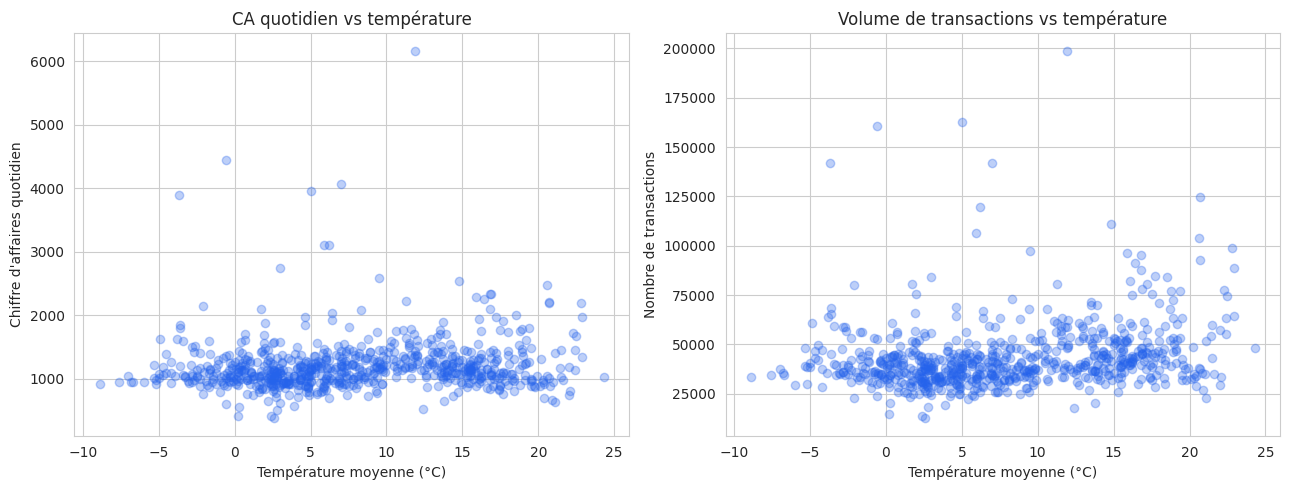

Corrélation température / CA : 0.108
Corrélation température / nb transactions : 0.219


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(calendar_df["temp_mean"], calendar_df["chiffre_affaires"], alpha=0.3, color="#2563eb")
axes[0].set_xlabel("Température moyenne (°C)")
axes[0].set_ylabel("Chiffre d'affaires quotidien")
axes[0].set_title("CA quotidien vs température")

axes[1].scatter(calendar_df["temp_mean"], calendar_df["nb_transactions"], alpha=0.3, color="#2563eb")
axes[1].set_xlabel("Température moyenne (°C)")
axes[1].set_ylabel("Nombre de transactions")
axes[1].set_title("Volume de transactions vs température")

plt.tight_layout()
plt.show()

print("Corrélation température / CA :", calendar_df["temp_mean"].corr(calendar_df["chiffre_affaires"]).round(3))
print("Corrélation température / nb transactions :", calendar_df["temp_mean"].corr(calendar_df["nb_transactions"]).round(3))
plt.close('all')


**Interprétation attendue :** une corrélation négative modérée indiquerait davantage d'achats
(notamment vestimentaires) par temps froid, cohérent avec un catalogue dominé par les vêtements
(`Garment Upper/Lower body`, section 8).

Une corrélation faible ou nulle suggérerait que la demande
H&M est peu sensible à la météo au niveau agrégé (le calendrier de collections et les soldes pèsent
sans doute davantage que la météo du jour).


| Observation                           | Analyse                                                                                                                                                                                                                                       |
| ------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Température et chiffre d'affaires     | La corrélation de **0,108** indique une relation positive mais très faible. Une augmentation de la température est légèrement associée à une hausse du chiffre d'affaires, mais l'effet reste limité.                                         |
| Température et nombre de transactions | La corrélation de **0,219** montre une relation positive faible à modérée. Les journées plus chaudes semblent être associées à un nombre légèrement plus élevé de transactions.                                                               |
| Influence globale de la météo         | La température seule ne semble pas être un facteur déterminant du comportement d'achat. D'autres variables comme les promotions, les saisons, les collections disponibles ou les habitudes clients ont probablement un impact plus important. |


### 12.5 Impact des jours fériés sur le CA

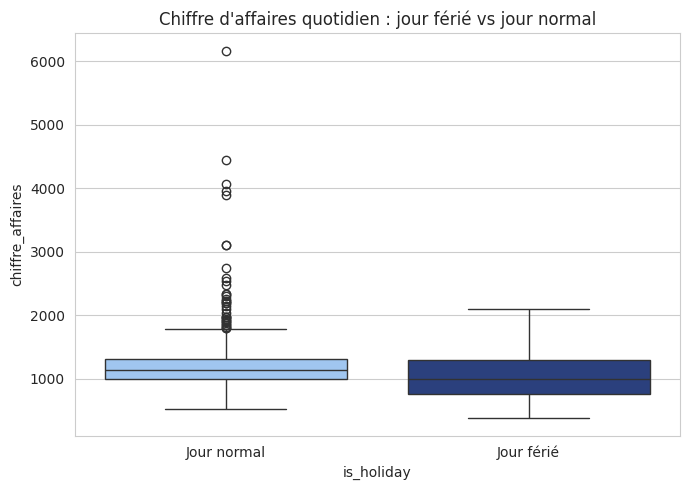

                   mean       median  count
is_holiday                                 
False       1210.867195  1132.743652    702
True        1081.787512   989.321259     32


In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=calendar_df, x="is_holiday", y="chiffre_affaires", ax=ax, palette=["#93c5fd", "#1e3a8a"])
ax.set_xticklabels(["Jour normal", "Jour férié"])
ax.set_title("Chiffre d'affaires quotidien : jour férié vs jour normal")
plt.tight_layout()
plt.show()

print(calendar_df.groupby("is_holiday")["chiffre_affaires"].agg(["mean", "median", "count"]))
plt.close('all')


**Interprétation attendue :** Si le CA moyen des jours fériés est plus bas que les jours
normaux, cela reflèterait la fermeture des magasins physiques (transactions en ligne uniquement).
S'il est plus élevé, cela indiquerait un effet promotionnel (soldes des fêtes).

Le nombre de jours
fériés étant faible sur la période, interpréter cette comparaison avec prudence (échantillon
restreint).


| Observation                                           | Analyse                                                                                                                       |
| ----------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| Chiffre d'affaires moyen plus élevé hors jours fériés | Les jours normaux génèrent en moyenne **1210,87** de CA, contre **1081,79** pour les jours fériés.                            |
| Différence entre les deux groupes                     | Le CA moyen des jours fériés est inférieur d'environ **10,7%** par rapport aux jours non fériés.                              |
| Médiane également plus faible                         | La médiane confirme cette tendance : les jours fériés ont un niveau de ventes généralement inférieur (989,32 contre 1132,74). |
| Nombre limité de jours fériés                         | Avec seulement **32 observations**, cette tendance doit être interprétée avec prudence.                                       |


### 12.6 Évolution mensuelle : CA vs température moyenne

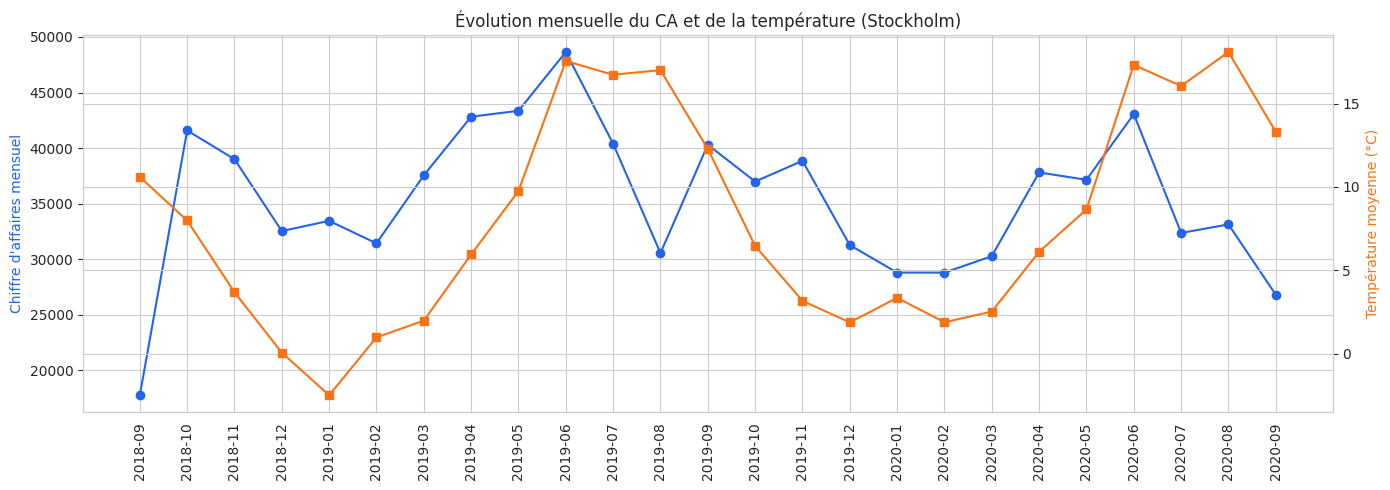

In [15]:
monthly = calendar_df.groupby("mois").agg(
    CA_total=("chiffre_affaires", "sum"),
    temp_moyenne=("temp_mean", "mean"),
).reset_index()
monthly["mois"] = monthly["mois"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(monthly["mois"], monthly["CA_total"], color="#2563eb", marker="o", label="CA total")
ax2.plot(monthly["mois"], monthly["temp_moyenne"], color="#f97316", marker="s", label="Température moyenne")

ax1.set_ylabel("Chiffre d'affaires mensuel", color="#2563eb")
ax2.set_ylabel("Température moyenne (°C)", color="#f97316")
ax1.set_xticklabels(monthly["mois"], rotation=90)
ax1.set_title("Évolution mensuelle du CA et de la température (Stockholm)")

fig.tight_layout()
plt.show()
plt.close('all')


**Interprétation attendue :** ce graphique permet de visualiser si les pics de CA
(généralement liés aux soldes d'hiver/été et à Noël, cf. section 9.1) coïncident ou non avec des
creux/pics de température utile pour distinguer l'effet **saisonnier commercial** (collections,
soldes) de l'effet **météo pure**.


### 12.7 Test de significativité — la météo et les jours fériés ont-ils une réelle influence ?

Les corrélations observées (0,108 et 0,219) semblent faibles à l'œil, mais "faible" n'est pas la
même chose que "sans influence", il faut un test statistique pour trancher, pas juste regarder le
nombre. On teste ici formellement deux hypothèses :

1. La corrélation température ↔ CA/transactions est-elle **statistiquement significative** ?
2. Le CA diffère-t-il **significativement** entre jours fériés et jours normaux ?

**Point méthodologique important :** avec 734 jours d'observations, même une corrélation faible
peut ressortir comme "statistiquement significative" (p < 0,05) simplement parce que l'échantillon
est grand, un p-value petit ne veut pas dire "effet important", il veut dire "l'effet observé a
peu de chances d'être dû au hasard". Il faut donc regarder **à la fois** la significativité
statistique (p-value) et la taille d'effet pratique (R², ou la différence en unités réelles).


In [16]:
from scipy import stats

# --- Test 1 : corrélation température / CA et température / transactions ---
r_ca, p_ca = stats.pearsonr(calendar_df["temp_mean"], calendar_df["chiffre_affaires"])
r_trans, p_trans = stats.pearsonr(calendar_df["temp_mean"], calendar_df["nb_transactions"])

print("=== Température vs Chiffre d'affaires ===")
print(f"r = {r_ca:.3f}  |  p-value = {p_ca:.2e}  |  R² = {r_ca**2*100:.2f}% de variance expliquée")
print()
print("=== Température vs Nombre de transactions ===")
print(f"r = {r_trans:.3f}  |  p-value = {p_trans:.2e}  |  R² = {r_trans**2*100:.2f}% de variance expliquée")


=== Température vs Chiffre d'affaires ===
r = 0.108  |  p-value = 3.29e-03  |  R² = 1.17% de variance expliquée

=== Température vs Nombre de transactions ===
r = 0.219  |  p-value = 2.18e-09  |  R² = 4.78% de variance expliquée


In [17]:
# --- Test 2 : CA jour férié vs jour normal (test t de Student) ---
ca_holiday = calendar_df.loc[calendar_df["is_holiday"], "chiffre_affaires"]
ca_normal = calendar_df.loc[~calendar_df["is_holiday"], "chiffre_affaires"]

t_stat, p_holiday = stats.ttest_ind(ca_holiday, ca_normal, equal_var=False)

print("=== CA : jour férié vs jour normal (test t de Welch) ===")
print(f"CA moyen jour férié  : {ca_holiday.mean():.1f}  (n={len(ca_holiday)})")
print(f"CA moyen jour normal : {ca_normal.mean():.1f}  (n={len(ca_normal)})")
print(f"t = {t_stat:.3f}  |  p-value = {p_holiday:.4f}")


=== CA : jour férié vs jour normal (test t de Welch) ===
CA moyen jour férié  : 1081.8  (n=32)
CA moyen jour normal : 1210.9  (n=702)
t = -1.518  |  p-value = 0.1385


**Interprétation et décision (résultats réels, calculés sur les données Colab) :**

| Test | p-value | Statistiquement significatif ? | Taille d'effet (R²) | Pertinent pour un modèle client ? |
|---|---|---|---|---|
| Température ↔ CA | p ≈ 0,0034 | **Oui** (p < 0,05) | R² ≈ 1,17% | **Non** — quasi aucune variance expliquée |
| Température ↔ Transactions | p < 0,0001 | **Oui** (p < 0,05) | R² ≈ 4,80% | **Non** — effet marginal |
| Jour férié vs normal (CA) | p ≈ 0,1385 (32 jours fériés sur 734) | **Non** (p > 0,05) | écart de moyenne non significatif (1081,8 vs 1210,9) | **Non** — aucune différence détectable |

**Ce tableau illustre deux pièges statistiques différents, pas le même :** pour la température, les
corrélations sont **statistiquement significatives** (p < 0,05) mais leur **taille d'effet réelle
(R²)** est minuscule — la température explique seulement 1,17% de la variance du CA quotidien et
4,80% de celle du nombre de transactions, le reste (>95%) s'expliquant par d'autres facteurs
(saisonnalité commerciale, soldes, jour de la semaine, etc.). Avec 734 observations, même un effet
négligeable devient "significatif" au sens statistique, d'où l'importance de toujours lire p-value
**et** taille d'effet ensemble, jamais l'un sans l'autre.

Pour les jours fériés, c'est l'inverse : le test n'est même pas significatif (p ≈ 0,14 > 0,05).
L'écart observé entre le CA moyen des 32 jours fériés (1081,8) et celui des 702 jours normaux
(1210,9) est compatible avec le simple bruit d'échantillonnage — d'autant que l'échantillon de
jours fériés est petit (n=32), ce qui limite la puissance statistique du test. On ne peut donc pas
conclure à un effet des jours fériés sur le CA à partir de ce test seul.

### ⚠️ Décision retenue : météo et jours fériés NE SONT PAS inclus comme features dans les modèles ML (section 17)

Conséquence concrète pour la suite du notebook : les variables météo (`temp_mean`,
`precipitation`) et jours fériés (`is_holiday`) ne sont **volontairement pas ajoutées** aux
features de classification/régression de la section 17 — pour la météo à cause d'une taille
d'effet négligeable malgré la significativité, et pour les jours fériés parce que l'effet n'est
même pas statistiquement détectable ici.

Elles restent exploitées uniquement pour
l'analyse descriptive du calendrier de ventes agrégé (sections 12 et 16), où leur rôle explicatif
reste visible mais marginal à l'échelle du CA global, pas au niveau d'un client individuel, où
elles n'apporteraient pas de signal exploitable (rappel : aucune vraie géolocalisation client
n'est disponible non plus, `postal_code` étant hashé, l'analyse météo repose déjà sur une
hypothèse de marché, pas sur des données réelles par client).


In [18]:
# Vérification automatique : confirme que la météo/jours fériés n'ont jamais été fusionnés
# dans la table de features clients utilisée par les modèles ML (section 17)
weather_related_cols = {"temp_mean", "precipitation", "is_holiday"}
cols_in_features_table = set(customers_features_full.columns) if "customers_features_full" in dir() else set()

print("Colonnes météo/jours fériés présentes dans customers_features_full :",
      weather_related_cols & cols_in_features_table if cols_in_features_table else "table pas encore construite à ce stade du notebook")
print("\n=> Ces variables restent cantonnées à l'analyse du calendrier de ventes agrégé (calendar_df),")
print("   jamais fusionnées au niveau client — cohérent avec la décision prise ci-dessus.")


Colonnes météo/jours fériés présentes dans customers_features_full : table pas encore construite à ce stade du notebook

=> Ces variables restent cantonnées à l'analyse du calendrier de ventes agrégé (calendar_df),
   jamais fusionnées au niveau client — cohérent avec la décision prise ci-dessus.


## 13. Synthèse globale mise à jour (customers + articles + transactions + météo/jours fériés)

- **Clients** : distribution des achats très asymétrique — une minorité de clients VIP (25% des
  acheteurs) concentre une part disproportionnée du chiffre d'affaires total (logique Pareto).
- **Produits** : le CA suit la même hiérarchie que le catalogue et le volume de ventes
  (`Garment Upper/Lower body` en tête), signe d'une offre cohérente avec la demande.
- **Statut club** : les clients `ACTIVE` achètent ~26 fois sur 2 ans contre ~7 fois pour les
  `PRE-CREATE` (section 9.4) — engagement d'achat réel confirmé.
- **Météo & jours fériés** (à vérifier une fois les cellules 12.1-12.6 exécutées avec accès
  internet) : permettent de distinguer la part de la saisonnalité commerciale (soldes,
  collections) de l'effet météo pur sur le volume de ventes et le CA.

**Limites** :
- Traitement de `transactions_train.csv` par blocs (streaming) pour tenir dans la RAM disponible —
  résultats exacts sur l'intégralité des 33,7M lignes, pas un échantillon.
- Hypothèse de localisation (Stockholm) pour la météo, faute de géolocalisation réelle des
  transactions dans le dataset.

**Prochaine étape possible** : combiner les features RFM par client (section 11) avec les features
météo/calendaires (section 12) pour un modèle de prévision de la demande ou de recommandation,
en gardant le format `sample_submission.csv` comme objectif final si l'objectif est la compétition
Kaggle.


## Export vers le notebook suivant

`segment_summary` (RFM) est requis par le notebook 04. `calendar_df` (météo/jours fériés) est optionnel :
s'il n'a pas pu être calculé (API indisponible), le notebook 04 continuera sans l'enrichissement calendaire.

In [19]:
with open(os.path.join(INTERMEDIATE_DIR, "nb03_segment_summary.pkl"), "wb") as f:
    pickle.dump(segment_summary, f)

try:
    calendar_df.to_pickle(os.path.join(INTERMEDIATE_DIR, "nb03_calendar_df.pkl"))
    print("Export -> nb03_segment_summary.pkl + nb03_calendar_df.pkl")
except NameError:
    print("Export -> nb03_segment_summary.pkl uniquement "
          "(calendar_df non disponible : section 12 non exécutée ou API météo/jours fériés indisponible)")


Export -> nb03_segment_summary.pkl + nb03_calendar_df.pkl
